# Section 5.2: Distributional Regression on Bike Sharing

Reproduces **Figure 2** of the paper plus **Figures D.2 (instance overview) and D.3 (SHAP vs. Entropy-Shapley)** from Appendix D.2.1.

We move from the controlled synthetic DGP (Sec. 5.1) to a real distributional-regression problem: predicting bike rentals on the UCI Bike Sharing dataset, aggregated into $T = 8$ two-hour blocks between 06:00 and 22:00, from $p = 8$ daily features:

- three 06:00 weather snapshots (`temp_6am`, `hum_6am`, `windspeed_6am`),
- the seven-day mean temperature (`temp_week_mean`),
- previous-day total rentals (`cnt_prev1`),
- three calendar features (`workingday`, `weekday`, `yr`).

The model is **NGBoost** with a multivariate-normal target, which yields a feature-dependent mean $\boldsymbol{\mu}(\mathbf{x})$ and full covariance $\boldsymbol{\Sigma}(\mathbf{x})$. Because the predictive distribution is closed-form Gaussian, the entire hierarchy admits closed-form values (Sec. 4.2.1).

We contrast a **workday** (low uncertainty, bimodal commute profile) with a **weekend** (high uncertainty) to show how each level highlights a different structural aspect of the predictive distribution. Appendix D.2.1 then puts the hierarchy side-by-side with TreeSHAP applied to the predicted mean, demonstrating that mean-attribution and uncertainty-attribution can diverge substantially.

Figures are written to `plots/5_2/`, the trained model to `models/ngboost_bikesharing.pkl`, and intermediate caches (Shapley values, TreeSHAP) to `results/5_2/`.

> **Note.** This notebook is intended to be executed top-to-bottom in a single run (e.g. *Run All*). The global NumPy RNG is seeded once at the top, so re-running individual cells out of order can change the background sample and shift Shapley values by Monte-Carlo noise.
>
> The global SHAP / hierarchy run uses `N_PARALLEL_GLOBAL = 32` threads by default. Adjust this value to your system.


In [1]:
import sys, os, time
sys.path.insert(0, os.path.join(os.path.abspath(""), ".."))
start_time = time.time()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import norm
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from ngboost import NGBRegressor
from ngboost.distns import MultivariateNormal
from lightgbm import LGBMRegressor
from sklearn.tree import DecisionTreeRegressor
import pickle

from entropy_shapley import MarginalTabularSampler, GaussianImputer, HierarchyGame

# Create dirs
plot_dir = "../plots/5_2/"
res_dir = "../results/5_2/"
model_dir = "../models/"
os.makedirs(model_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(res_dir, exist_ok=True)

# Set seed
seed = 123
np.random.seed(seed)

# Set number of prallel processes (adjust based on your machine)
N_PARALLEL = 8
N_PARALLEL_GLOBAL = 32

## 1) Dataset: UCI Bike Sharing

The dataset contains hourly bike rental counts across two years. We restrict to the active hours 6–22h and aggregate each day into $T = 8$ blocks of 2 hours each. The raw dataset consists of the following features:

| Feature | Type | Description |
|---------|------|-------------|
| `cnt`     | cont  | number of bike rantals **(outcome $Y$)** |
| `workingday` | binary | is a workingday? Yes/No |
| `weekday` | cat | 0 = Sun, ..., 6 = Sat |
| `temp` | cont | normalized temperature |
| `hum` | cont | normalized humidity |
| `windspeed` | cont | normalized wind speed |
| `yr`/`month`/`hr`      |  cat |  other daytime features 

**Note:** To keep the number of playes and features small, we excluded the other features.

In [2]:
START_HR   = 6
END_HR     = 22
BLOCK_HRS  = 2
T          = (END_HR - START_HR) // BLOCK_HRS   # = 8
Y_SCALE    = 100.0   # scale targets to same range as cnt_prev1 (already /100)
DATA_PATH = '../datasets/bikesharing_hour.csv'

FEATURES_CAT      = ['workingday', 'weekday', 'yr'] #'weathersit',
FEATURES_CONT_6AM = ['temp_6am', 'hum_6am', 'windspeed_6am']
FEATURES_CONT     = FEATURES_CONT_6AM + ['temp_week_mean', 'cnt_prev1']
FEATURES          = FEATURES_CONT + FEATURES_CAT
FEATURE_LABELS    = ['Temp 6am', 'Hum 6am', 'Wind 6am', 'Week Temp',
                     'Prev Count', 'Workday', 'Weekday', 'Year']

# Load  dataset and filter to relevant hours (6am-10pm)
df = pd.read_csv(DATA_PATH, parse_dates=['dteday'])
df = df.sort_values(['dteday', 'hr']).reset_index(drop=True)
df = df[(df['hr'] >= START_HR) & (df['hr'] < END_HR)].copy()
df['block'] = (df['hr'] - START_HR) // BLOCK_HRS

# Use the first entry for each categorical feature per day (they are constant across the day)
day_feats = df.groupby('dteday')[FEATURES_CAT].first().reset_index().sort_values('dteday').reset_index(drop=True)

# Compute daily mean temp and cnt to use as features (and drop later to avoid leakage)
temp_mean = df.groupby('dteday')['temp'].mean().rename('temp_daily').reset_index()
cnt_mean  = (df.groupby('dteday')['cnt'].mean() / Y_SCALE).rename('cnt_total').reset_index()
day_feats = day_feats.merge(temp_mean, on='dteday').merge(cnt_mean, on='dteday')

# Create lag features (shifted by 1 day to avoid leakage)
day_feats['cnt_prev1']      = day_feats['cnt_total'].shift(1)
day_feats['temp_week_mean'] = day_feats['temp_daily'].shift(1).rolling(7).mean()

# Get 6am observations to use as features (and drop later to avoid leakage)
obs_6am = (df[df['hr'] == START_HR]
           [['dteday', 'temp', 'hum', 'windspeed']]
           .rename(columns={'temp': 'temp_6am', 'hum': 'hum_6am', 'windspeed': 'windspeed_6am'}))
day_feats = day_feats.merge(obs_6am, on='dteday', how='left')
day_feats = day_feats.drop(columns=['temp_daily', 'cnt_total']).dropna().reset_index(drop=True)

# Create target variables: total count in each block of hours (e.g. 6-8am, 8-10am, etc.)
blocks = (df.groupby(['dteday', 'block'])['cnt'].sum().unstack(level='block', fill_value=0).reset_index())
blocks.columns = ['dteday'] + [f'Y_b{b}' for b in range(T)]

# Merge features and targets, shuffle, and split into train/test sets
daily = day_feats.merge(blocks, on='dteday').dropna().reset_index(drop=True)
daily = daily.sample(frac=1, random_state=2026).reset_index(drop=True)
X = daily[FEATURES]
Y = daily[[f'Y_b{b}' for b in range(T)]].values.astype(float)
n_test = int(0.2 * len(daily))
X_train, X_test = X[:-n_test], X[-n_test:]
Y_train, Y_test = Y[:-n_test], Y[-n_test:]

# Scale targets to same order of magnitude as features (cnt_prev1 already /100)
Y_train = Y_train / Y_SCALE
Y_test  = Y_test  / Y_SCALE

# Create one-hot encoder 
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe.fit(X[FEATURES_CAT])
OHE_COLS = ohe.get_feature_names_out(FEATURES_CAT).tolist()
ENC_COLS  = FEATURES_CONT + OHE_COLS

# Helper function: encode categorical features and concatenate with continuous features
def encode_df(df: pd.DataFrame) -> pd.DataFrame:
    cat = pd.DataFrame(ohe.transform(df[FEATURES_CAT]), columns=OHE_COLS, index=df.index)
    return pd.concat([df[FEATURES_CONT].reset_index(drop=True),
                      cat.reset_index(drop=True)], axis=1)
# Create encoded versions of train/test sets
X_train_enc = encode_df(X_train)
X_test_enc  = encode_df(X_test)

# Define number of features and block labels for later use
p            = X_train.shape[1]
BLOCK_LABELS = [f'{START_HR + BLOCK_HRS*b:02d}-{START_HR + BLOCK_HRS*(b+1) - 1:02d}h'
                for b in range(T)]

print(f'Days total: {len(daily)} | Train: {len(X_train)}, Test: {len(X_test)}')
X_train_enc.describe().T

Days total: 718 | Train: 575, Test: 143


,count,mean,std,min,25%,50%,75%,max
temp_6am,575.0,0.441878,0.176131,0.020000,0.300000,0.440000,0.600000,0.80000
hum_6am,575.0,0.740104,0.156128,0.170000,0.640000,0.770000,0.870000,1.00000
windspeed_6am,575.0,0.159357,0.108598,0.000000,0.089600,0.134300,0.223900,0.58210
temp_week_mean,575.0,0.526389,0.180108,0.161667,0.361071,0.533214,0.698393,0.84875
cnt_prev1,575.0,2.650702,1.099565,0.242500,1.907500,2.655000,3.470000,4.83625
workingday_1,575.0,0.690435,0.462717,0.000000,0.000000,1.000000,1.000000,1.00000
weekday_1,575.0,0.130435,0.337074,0.000000,0.000000,0.000000,0.000000,1.00000
weekday_2,575.0,0.144348,0.351748,0.000000,0.000000,0.000000,0.000000,1.00000
weekday_3,575.0,0.149565,0.356955,0.000000,0.000000,0.000000,0.000000,1.00000
weekday_4,575.0,0.144348,0.351748,0.000000,0.000000,0.000000,0.000000,1.00000


We visualize the average bike rental patterns across 2-hour blocks,
comparing working days and weekends/holidays.
This reveals the distinctive demand profiles that NGBoost will need to model:
- **Weekday**: bimodal distribution with commute peaks (morning and evening)
- **Weekend**: flatter, more uniform distribution with midday leisure demand

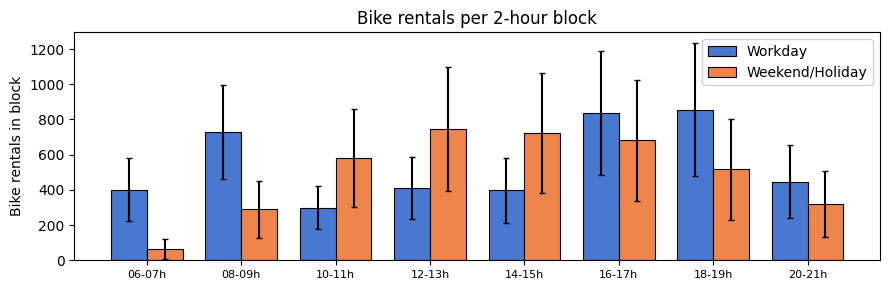

In [3]:
workday_mask = X_train['workingday'] == 1
Y_wd  = Y_train[workday_mask]
Y_we  = Y_train[~workday_mask]

# Calculate mean and sd for error bars (scaled back to original range)
wd_mean, wd_se = Y_wd.mean(axis=0) * Y_SCALE, Y_wd.std(axis=0) * Y_SCALE
we_mean, we_se = Y_we.mean(axis=0) * Y_SCALE, Y_we.std(axis=0) * Y_SCALE

# Plot mean bike rentals per block with error bars for workdays vs weekends/holidays
x = np.arange(len(BLOCK_LABELS))
bw = 0.38
colors = sns.color_palette("muted", n_colors=2).as_hex()
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(x - bw/2, wd_mean, bw, yerr=wd_se, label='Workday',
       color=colors[0], edgecolor='black', lw=0.8, capsize=2)
ax.bar(x + bw/2, we_mean, bw, yerr=we_se, label='Weekend/Holiday',
       color=colors[1], edgecolor='black', lw=0.8, capsize=2)
ax.set_xticks(x)
ax.set_xticklabels(BLOCK_LABELS, fontsize=8)
ax.set_ylabel('Bike rentals in block')
ax.set_title('Bike rentals per 2-hour block')
ax.legend(framealpha=0.9)
fig.tight_layout()
plt.show()

## 2) Model: NGBoost with Multivariate Normal Output

NGBoost [(Duan et al., 2020)](https://proceedings.mlr.press/v119/duan20a/duan20a.pdf) fits a probabilistic gradient boosting model.
Using `MultivariateNormal(T)` as the distribution gives us a full
**feature-dependent covariance matrix** $\boldsymbol{\Sigma}(\mathbf{x})$ —
exactly what we need to define all three entropy levels.

In [4]:
# Train (or load cached) NGBoost
MODEL_PATH = model_dir + "ngboost_bikesharing.pkl"
if os.path.exists(MODEL_PATH):
    with open(MODEL_PATH, "rb") as f:
        model = pickle.load(f)
    print(f"✓ Loaded cached model from {MODEL_PATH}")
else:
    model = NGBRegressor(
        Dist=MultivariateNormal(T),
        Base = DecisionTreeRegressor(max_depth=2),
        n_estimators=1500,
        learning_rate=0.01,
        minibatch_frac=0.8,
        verbose_eval=100,
        early_stopping_rounds=100,
        random_state=seed,
    )
    model = model.fit(X_train_enc, Y_train, X_val=X_test_enc, Y_val=Y_test)
    print('✓ Training complete.')
    with open(MODEL_PATH, "wb") as f:
        pickle.dump(model, f)
    print(f"✓ Model saved to {MODEL_PATH}")

# Evaluate (rescale back to original units for display)
Y_pred = model.predict(X_test_enc) * Y_SCALE
rmse = np.sqrt(np.mean((Y_test * Y_SCALE - Y_pred) ** 2))
print(f'✓ Evaluation (RMSE: {rmse:.2f}).')

# Save data caches (no-op if files already exist)
if not os.path.exists(res_dir + "x_train.csv"):
    X_train.to_csv(res_dir + "x_train.csv")
    X_train_enc.to_csv(res_dir + "x_train_enc.csv")
    X_test.to_csv(res_dir + "x_test.csv")
    X_test_enc.to_csv(res_dir + "x_test_enc.csv")
    np.save(res_dir + "y_train.npy", Y_train)
    np.save(res_dir + "y_test.npy", Y_test)
    print(f"✓ Data caches saved to {res_dir}")


Using passed validation data to check for early stopping.
[iter 0] loss=12.3221 val_loss=11.7929 scale=0.0625 norm=0.6541
[iter 100] loss=11.7078 val_loss=11.4363 scale=0.2500 norm=2.2974
[iter 200] loss=11.0307 val_loss=11.0434 scale=0.2500 norm=2.0230
[iter 300] loss=10.6277 val_loss=10.7242 scale=0.2500 norm=1.8853
[iter 400] loss=10.1641 val_loss=10.4250 scale=0.2500 norm=1.7854
[iter 500] loss=9.8711 val_loss=10.1901 scale=0.2500 norm=1.7598
[iter 600] loss=9.5367 val_loss=9.9499 scale=0.2500 norm=1.7194
[iter 700] loss=8.9500 val_loss=9.6867 scale=0.5000 norm=3.3778
[iter 800] loss=8.6793 val_loss=9.4958 scale=0.2500 norm=1.7265
[iter 900] loss=8.4332 val_loss=9.3538 scale=0.2500 norm=1.7705
[iter 1000] loss=8.1516 val_loss=9.2593 scale=0.2500 norm=1.8091
[iter 1100] loss=7.8200 val_loss=9.2013 scale=0.2500 norm=1.8483
[iter 1200] loss=7.6094 val_loss=9.1685 scale=0.2500 norm=1.9063
[iter 1300] loss=7.4360 val_loss=9.1615 scale=0.2500 norm=1.9584
[iter 1400] loss=7.2582 val_loss=

## 3) Model Evaluation

We compare NGBoost against three baselines on point prediction accuracy (RMSE):
- **Mean baseline**: predicts the training mean $\bar{\mathbf{y}}$ for every day.
- **MLR**: multivariate linear regression (one model for all blocks).
- **LightGBM**: strong non-linear baseline (independent per block).

We then assess NGBoost's **probabilistic calibration** separately via a coverage plot. For each nominal confidence level, we check what fraction of test observations fall inside the predicted interval.

In [5]:
# Helper function: convert covariance matrix to correlation matrix
def cov_to_corr(S):
    d = np.sqrt(np.diag(S))
    return S / np.outer(d, d)

# Helper function: get predicted means and covariances from NGBoost, rescaled to original units
def pred_func(X: pd.DataFrame):
    X_enc = encode_df(X)
    dist  = model.pred_dist(X_enc)
    return dist.params['loc'] * Y_SCALE, dist.params['scale'] * Y_SCALE**2

# Helper function: RMSE
def rmse(y_true, y_pred):
    return np.sqrt(((y_true - y_pred) ** 2).mean())

# Get predicted means and covariances from NGBoost, rescaled to original units
ngb_dist  = model.pred_dist(X_test_enc)
mu_ngb    = ngb_dist.params['loc']   * Y_SCALE       # rescale to original rental units
Sigma_ngb = ngb_dist.params['scale'] * Y_SCALE**2    # covariance: σ² scales as Y_SCALE²
sigma_ngb = np.sqrt(np.array([np.diag(Sigma_ngb[i]) for i in range(len(X_test_enc))]))

# Original scale for RMSE / calibration comparisons
Y_test_orig = Y_test * Y_SCALE   # original scale for RMSE / calibration comparisons
mu_mean = np.tile(Y_train.mean(axis=0) * Y_SCALE, (len(X_test_enc), 1))

# Fit LightGBM and MLR baselines for comparison (rescaled to original units for display)
lgbm_mu = np.zeros((len(X_test_enc), T))
for t in range(T):
    gb = LGBMRegressor(n_estimators=1000, learning_rate=0.05, verbose=-1,
                       random_state=seed)
    gb.fit(X_train_enc, Y_train[:, t], eval_set=[(X_test_enc, Y_test[:, t])])
    lgbm_mu[:, t] = gb.predict(X_test_enc) * Y_SCALE
mlr = MultiOutputRegressor(LinearRegression())
mlr.fit(X_train_enc, Y_train)
mlr_mu = mlr.predict(X_test_enc) * Y_SCALE

# Print RMSE for NGBoost and baselines
print(f"{'Model':<19} {'RMSE':>15}")
print('-' * 40)
for name, mu_ in [('Mean baseline',                  mu_mean),
                   ('MLR',                           mlr_mu),
                   ('LightGBM',                      lgbm_mu),
                   ('NGBoost (to be explained)',     mu_ngb)]:
    print(f'{name:<25} {rmse(Y_test_orig, mu_):>10.1f}')

Model                          RMSE
----------------------------------------
Mean baseline                  281.6
MLR                            128.1
LightGBM                       132.7
NGBoost (to be explained)      121.5


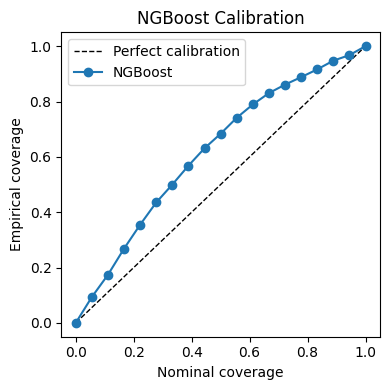

In [6]:
# Calibration plot: empirical coverage vs nominal coverage for NGBoost prediction intervals
nominal = np.linspace(0, 1, 19)
coverages = []
for alpha in 1 - nominal:
    z = norm.ppf(1 - alpha / 2)
    in_interval = (Y_test_orig >= mu_ngb - z * sigma_ngb) & \
                  (Y_test_orig <= mu_ngb + z * sigma_ngb)
    coverages.append(in_interval.mean())

fig, ax = plt.subplots(figsize=(4, 4))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.plot(nominal, coverages, 'o-', label='NGBoost')
ax.set_xlabel('Nominal coverage')
ax.set_ylabel('Empirical coverage')
ax.legend()
ax.set_title('NGBoost Calibration')
plt.tight_layout()
plt.savefig(plot_dir + 'calibration.pdf', bbox_inches='tight')
plt.show()

## 4) Visualization of two Contrasting Instances

We pick two days with structurally different rental profiles. The forecast ribbons show how NGBoost adapts mean and uncertainty to the day type.

In [7]:
X_test.loc[[609, 614]] 

,temp_6am,hum_6am,windspeed_6am,temp_week_mean,cnt_prev1,workingday,weekday,yr
609,0.62,0.61,0.1343,0.734821,3.15500,1,5,0
614,0.12,0.93,0.1940,0.221429,1.01375,0,6,0


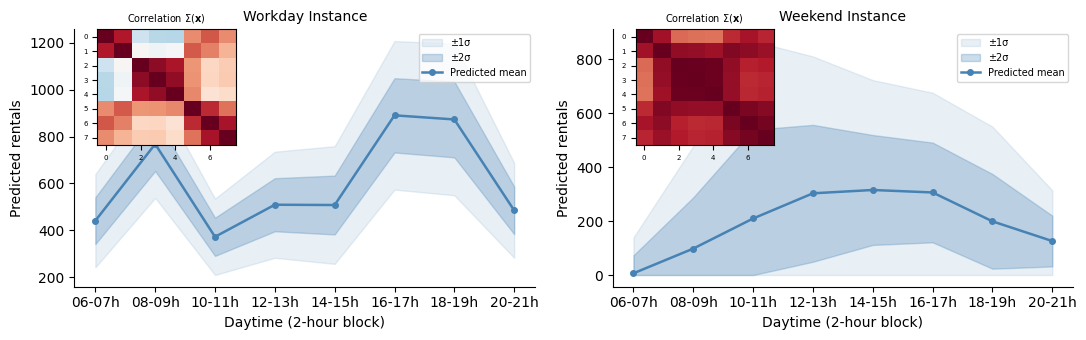

In [8]:
instances = [('Workday', X_test.loc[[609]]), ('Weekend', X_test.loc[[614]])]

max_rentals = 1700 #int(Y_test.max() * Y_SCALE * 1.15)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, (label, x_inst) in zip(axes, instances):
    mu, Sigma  = pred_func(x_inst)
    mu, Sigma = mu[0], Sigma[0]
    sigma_marg = np.sqrt(np.diag(Sigma))
    t_idx      = np.arange(1, T + 1)
    ax.fill_between(t_idx,   np.maximum(mu - 2*sigma_marg, 0), mu + 2*sigma_marg, alpha=0.12, color='steelblue')
    ax.fill_between(t_idx,  np.maximum(mu - sigma_marg, 0),   mu + sigma_marg,   alpha=0.28, color='steelblue')
    ax.plot(t_idx, mu, '-o', color='steelblue', lw=1.8, ms=4)
    ax.set_title(f'{label} Instance', fontsize=10)
    ax.set_xlabel('Daytime (2-hour block)')
    ax.set_ylabel('Predicted rentals')
    ax.set_xticks(t_idx)
    ax.legend(['±1σ', '±2σ', 'Predicted mean'], fontsize=7, loc='upper right')
    ax.set_xticklabels(BLOCK_LABELS)
    ax.spines[['top', 'right']].set_visible(False)
    ax_ins = ax.inset_axes([0.05, 0.55, 0.3, 0.45])
    R = cov_to_corr(Sigma)
    ax_ins.imshow(R, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax_ins.set_title(r'Correlation $\Sigma(\mathbf{x})$', fontsize=7)
    ax_ins.tick_params(labelsize=5)
plt.tight_layout()
plt.savefig(plot_dir + "prediction.pdf")
plt.show()


### Plot Prediction Including Feature Values (and Training Average)

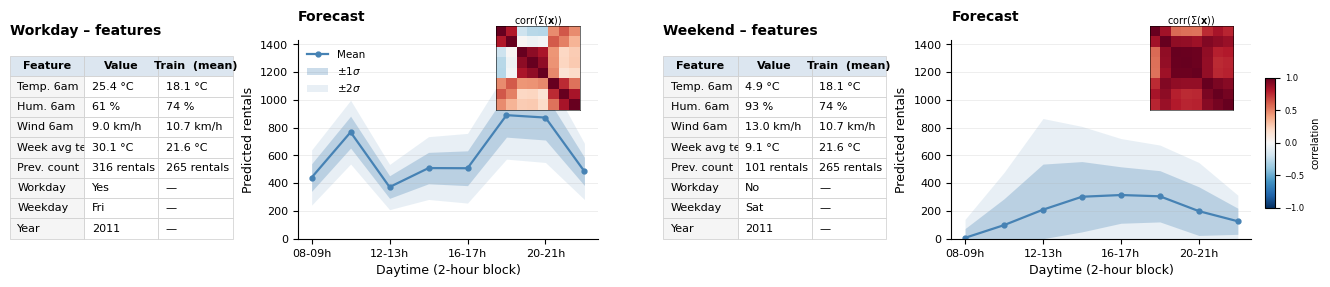

In [9]:
WEEKDAY_NAMES = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

# Pre-compute training-set means for continuous features (denormalized)
_m = X_train.mean()
CONT_MEANS = {
    'temp_6am':       _m['temp_6am']      * 41,
    'hum_6am':        _m['hum_6am']       * 100,
    'windspeed_6am':  _m['windspeed_6am'] * 67,
    'temp_week_mean': _m['temp_week_mean']* 41,
    'cnt_prev1':      _m['cnt_prev1']     * 100,
}

def denorm_rows(x_inst):
    r = x_inst.squeeze()
    m = CONT_MEANS
    return [
        ['Temp. 6am',      f"{r['temp_6am']       * 41:.1f} °C",   f"{m['temp_6am']:.1f} °C"],
        ['Hum. 6am',  f"{r['hum_6am']         * 100:.0f} %",  f"{m['hum_6am']:.0f} %"],
        ['Wind 6am',      f"{r['windspeed_6am']   * 67:.1f} km/h",f"{m['windspeed_6am']:.1f} km/h"],
        ['Week avg temp', f"{r['temp_week_mean']  * 41:.1f} °C",  f"{m['temp_week_mean']:.1f} °C"],
        ['Prev. count',   f"{int(round(r['cnt_prev1'] * 100))} rentals",
                          f"{int(round(m['cnt_prev1']))} rentals"],
        ['Workday',       'Yes' if r['workingday'] == 1 else 'No', '—'],
        ['Weekday',       WEEKDAY_NAMES[int(r['weekday'])],         '—'],
        ['Year',          str(2011 + int(r['yr'])),                 '—'],
    ]

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Pre-compute predictions to derive a shared y-limit across both forecasts
preds = [pred_func(x_inst) for _, x_inst in instances]
y_max = max((mu[0] + 2 * np.sqrt(np.diag(Sigma[0]))).max() for mu, Sigma in preds)
y_top = float(np.ceil(y_max / 100.0) * 100.0) * 1.1

fig = plt.figure(figsize=(13, 3.1))
gs  = fig.add_gridspec(
    1, 4,
    width_ratios=[1.15, 1.55, 1.15, 1.55],
    wspace=0.25,
    left=0.03, right=0.985, top=0.86, bottom=0.22,
)

forecast_axes = []
last_im = None
for i, ((label, x_inst), (mu_full, Sigma_full)) in enumerate(zip(instances, preds)):
    col_tab, col_plot = 2 * i, 2 * i + 1

    # Feature table
    ax_tab = fig.add_subplot(gs[0, col_tab])
    ax_tab.axis('off')
    tbl = ax_tab.table(
        cellText=denorm_rows(x_inst),
        colLabels=['Feature', 'Value', 'Train  (mean)'],
        cellLoc='left',
        loc='center',
        bbox=[0, 0, 1, 0.92],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor('#cccccc')
        cell.set_linewidth(0.5)
        if r == 0:
            cell.set_facecolor('#dce6f0')
            cell.set_text_props(fontweight='bold')
        elif c == 0:
            cell.set_facecolor('#f5f5f5')
    ax_tab.set_title(f'{label} – features', fontsize=10, fontweight='bold',
                     loc='left', pad=4)

    # Forecast plot with correlation-matrix inset
    sharey = forecast_axes[0] if forecast_axes else None
    ax = fig.add_subplot(gs[0, col_plot], sharey=sharey)
    forecast_axes.append(ax)

    mu, Sigma = mu_full[0], Sigma_full[0]
    sigma = np.sqrt(np.diag(Sigma))
    t_idx = np.arange(T)

    ax.fill_between(t_idx, np.maximum(mu - 2*sigma, 0), mu + 2*sigma,
                    alpha=0.12, color='steelblue', linewidth=0)
    ax.fill_between(t_idx, np.maximum(mu - sigma,   0), mu + sigma,
                    alpha=0.28, color='steelblue', linewidth=0)
    ax.plot(t_idx, mu, '-o', color='steelblue', lw=1.6, ms=3.5)

    ax.set_xticks(np.arange(T, step = 2))
    ax.set_xticklabels(BLOCK_LABELS[1::2], rotation=0, fontsize=7.5) # ha='right',
    ax.set_xlabel('Daytime (2-hour block)', fontsize=9)
    ax.set_ylim(0, y_top)
    ax.set_ylabel('Predicted rentals', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3, lw=0.5)
    ax.tick_params(labelsize=8)
    ax.set_title(f'Forecast', fontsize=10, fontweight='bold',
                 loc='left', pad=4)

    # Inset: correlation matrix of Sigma(x)
    ax_ins = ax.inset_axes([0.62, 0.65, 0.36, 0.42])
    R = cov_to_corr(Sigma)
    last_im = ax_ins.imshow(R, vmin=-1, vmax=1, cmap='RdBu_r', aspect='equal')
    ax_ins.set_title(r'$\mathrm{corr}(\Sigma(\mathbf{x}))$', fontsize=7, pad=2)
    ax_ins.set_xticks([])
    ax_ins.set_yticks([])
    for s in ax_ins.spines.values():
        s.set_linewidth(0.4)

    if i == 0:
        ax.legend(
            handles=[
                Line2D([0], [0], color='steelblue', lw=1.6, marker='o', ms=3.5,
                       label='Mean'),
                Patch(facecolor='steelblue', alpha=0.28, label=r'$\pm 1\sigma$'),
                Patch(facecolor='steelblue', alpha=0.12, label=r'$\pm 2\sigma$'),
            ],
            fontsize=7.5, loc='upper left', frameon=False,
        )

# Shared colorbar for the two correlation insets
cbar_ax = fig.add_axes([0.995, 0.32, 0.008, 0.42])
cbar = fig.colorbar(last_im, cax=cbar_ax)
cbar.set_label('correlation', fontsize=7)
cbar.ax.tick_params(labelsize=6)

plt.savefig(plot_dir + 'instances_overview.pdf', bbox_inches='tight')
plt.show()


Show the feature importance for the prediction using TreeSHAP:

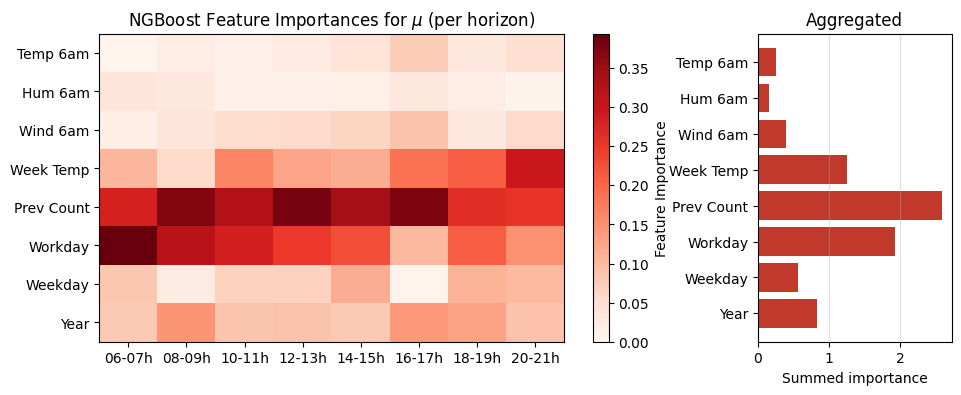

In [10]:
# Calculate feature importance for grouped features
encoded_feature_names = X_train_enc.columns.values
imp = model.feature_importances_   # (T + ((T * (T+1)/ 2), 16)
groups = [np.where((encoded_feature_names == feat) | np.char.startswith(encoded_feature_names.astype(str), feat + "_"))[0]
    for feat in FEATURES]
imp = np.column_stack([imp[:, idx].sum(axis=1) for idx in groups])  # (90, 8)

# Extract importances for μ (first T rows) and aggregate across horizons
imp_mu = imp[0:T, :]          # (T, p) — Importances for μ
imp_agg = imp_mu.sum(axis=0)  # (p,)  — aggregated across horizons

# Create plot 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={'width_ratios': [3, 1]})

# Heatmap
im = ax1.imshow(imp_mu.T, aspect='auto', cmap='Reds', vmin=0, vmax=imp_mu.max())
plt.colorbar(im, ax=ax1, label='Feature Importance')
ax1.set_yticks(np.arange(p))
ax1.set_yticklabels(FEATURE_LABELS)
ax1.set_xticks(np.arange(T))
ax1.set_xticklabels(BLOCK_LABELS)
ax1.set_title('NGBoost Feature Importances for $\\mu$ (per horizon)')

# Aggregated Barplot
ax2.barh(np.arange(p), imp_agg, color='#c0392b')
ax2.set_yticks(np.arange(p))
ax2.set_yticklabels(FEATURE_LABELS)
ax2.set_xlabel('Summed importance')
ax2.set_title('Aggregated')
ax2.grid(True, axis='x', alpha=0.4)
ax2.invert_yaxis()

# Save plot
plt.savefig(plot_dir + 'global_shap.pdf', bbox_inches='tight')
plt.show()

## 5) Entropy-Shapley Hierarchy

We compute Shapley values at all three levels for **both instances** simultaneously.

- `phi_L1[t, j]` = attribution of feature $j$ to $H(Y_t \mid \mathbf{x})$ (Level 1/marginal, horizon $t$)
- `phi_L2[t, j]` = attribution of feature $j$ to $H(Y_t \mid Y_{<t}, \mathbf{x})$ (Level 2/conditional, horizon $t$)
- `phi_L3[j]`    = attribution of feature $j$ to $H(\mathbf{Y} \mid \mathbf{x})$ (Level 3/joint)
- `phi_cross[j]` = $\sum_t \phi^{(t)}_j - \phi^{\text{joint}}_j$ — total correlation

Background: marginal sampler over training data ($N_{\text{MC}} =$ ` len(X_train)`).

In [11]:
# Define ngb_sigma as a top-level helper used by both the local and the global
# hierarchy computations and by the Prop. 1 / Prop. 2 verification cells.
N_MC = len(X_train)
x_train_array = X_train.values.astype(float)

def ngb_sigma(X_raw: np.ndarray) -> np.ndarray:
    """Raw feature array -> covariance matrices (n, T, T) in original rental units."""
    df = pd.DataFrame(X_raw, columns=FEATURES)
    df_enc = encode_df(df)
    out = model.pred_dist(df_enc).params['scale'] * Y_SCALE**2
    return out

# Local results: load cache or compute
LOCAL_PATH = res_dir + "entropySHAP_local.npy"
if os.path.exists(LOCAL_PATH):
    print(f"✓ Loading cached local Shapley values from {LOCAL_PATH}")
    all_results = np.load(LOCAL_PATH, allow_pickle=True).item()
else:
    all_results = {}
    X_instances = np.stack([x_inst.squeeze().values.astype(float) for _, x_inst in instances])

    # Main computation: create sampler, imputer, and game, then compute Shapley values for each instance and level
    sampler = MarginalTabularSampler(x_train_array, sample_size=N_MC)
    imputer = GaussianImputer(ngb_sigma, sampler, X_instances, T, n_jobs=N_PARALLEL)
    game    = HierarchyGame(imputer).precompute()

    # Extract Shapley values for each instance and level, then save to cache
    for i, (label, _) in enumerate(instances):
        phi_L1    = np.stack([game.game_L1(t, i).exact_values('SII', order=1).values[1:] for t in range(T)])
        phi_L2    = np.stack([game.game_L2(t, i).exact_values('SII', order=1).values[1:] for t in range(T)])
        phi_L3    = game.game_L3(i).exact_values('SII', order=1).values[1:]
        phi_cross = phi_L1.sum(axis=0) - phi_L3
        all_results[label] = dict(phi_L1=phi_L1, phi_L2=phi_L2, phi_L3=phi_L3, phi_cross=phi_cross)

    np.save(LOCAL_PATH, all_results)
    print(f"✓ Saved local Shapley values to {LOCAL_PATH}")


100%|██████████| 8/8 [01:05<00:00,  8.20s/it]

✓ Saved local Shapley values to ../results/5_2/entropySHAP_local.npy


## 6) Hierarchy Visualization

The figure has three rows:
- **Row 0**: forecast ribbons ($\pm 1\sigma$, $\pm 2\sigma$) for each instance
- **Rows 1–2**: per-instance hierarchy — L1/L2 heatmaps (feature × horizon)
  and L3/Cross horizontal barplots

In [12]:
# Load results
all_results = np.load(res_dir + "entropySHAP_local.npy", allow_pickle=True).item()

### Verification of Propositions 1 and 2

Sanity checks on the computed Shapley values for both instances:

- **Prop. 1 (chain rule):** $\varphi^{\text{joint}}_j = \sum_t \varphi^{(t|<t)}_j$.
- **Prop. 2 (cross = TC game):** $\sum_j \varphi^{\text{cross}}_j = \mathrm{TC}(Y\mid x) - \mathrm{TC}(Y\mid X)$,
  with the right-hand side computed analytically from the NGBoost covariance matrices over the training distribution.


In [13]:
def total_corr_gauss(S):
    """Total correlation of multivariate Gaussian: 0.5 * (sum log diag - log det)."""
    diag_log  = np.log(np.diagonal(S, axis1=-2, axis2=-1)).sum(axis=-1)
    _, logdet = np.linalg.slogdet(S)
    return 0.5 * (diag_log - logdet)

# E[TC(Y|X)] over the same background the imputer uses
TC_global = total_corr_gauss(ngb_sigma(x_train_array)).mean()

print(f"{'Instance':<10s} | {'Prop. 1 res.':>12s} | {'sum phi_cross':>13s} | {'TC(Y|x)-TC(Y|X)':>17s} | {'Prop. 2 res.':>12s}")
print('-' * 78)
for label, x_inst in instances:
    res     = all_results[label]
    phi_L2  = res['phi_L2'];  phi_L3 = res['phi_L3'];  phi_cross = res['phi_cross']
    p1_res  = float(np.max(np.abs(phi_L3 - phi_L2.sum(axis=0))))

    Sigma_x  = ngb_sigma(x_inst.values.astype(float))[0]
    TC_local = total_corr_gauss(Sigma_x)
    lhs, rhs = float(phi_cross.sum()), float(TC_local - TC_global)
    p2_res   = lhs - rhs
    print(f"{label:<10s} | {p1_res:12.2e} | {lhs:13.6f} | {rhs:17.6f} | {p2_res:12.2e}")


Instance   | Prop. 1 res. | sum phi_cross |   TC(Y|x)-TC(Y|X) | Prop. 2 res.
------------------------------------------------------------------------------
Workday    |     1.65e-14 |     -1.506034 |         -1.506034 |    -7.59e-14
Weekend    |     7.77e-15 |      3.866999 |          3.866999 |     4.35e-14


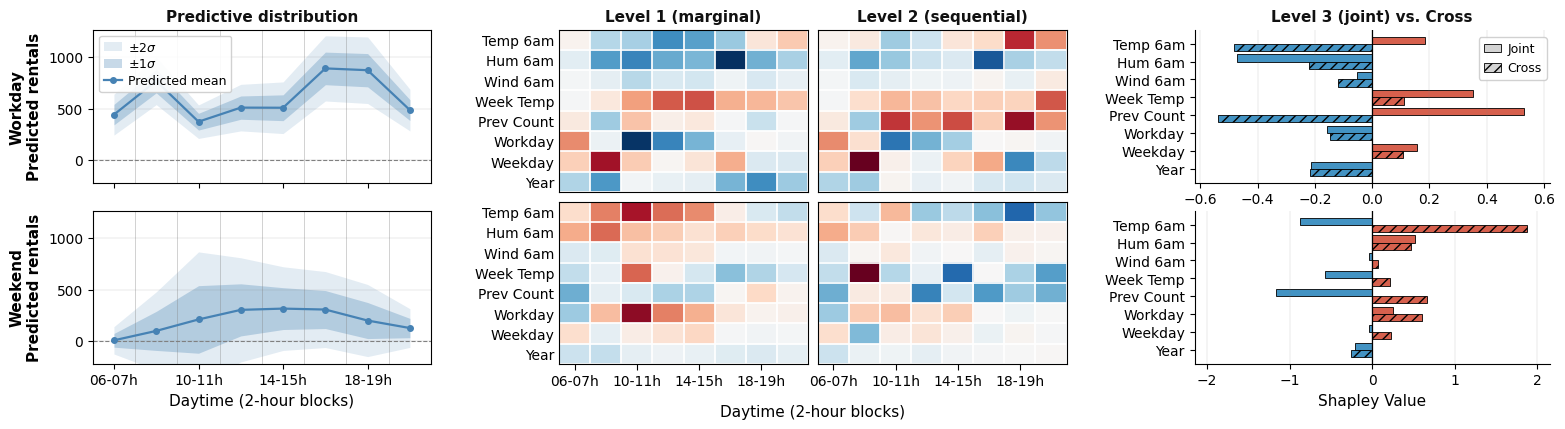

In [14]:
instances_df = pd.concat([x_inst for _, x_inst in instances], ignore_index=True)
inst_labels  = list(all_results.keys())

# Get results into arrays for easier plotting
all_phi_L1    = np.array([all_results[lbl]['phi_L1']    for lbl in inst_labels])
all_phi_L2    = np.array([all_results[lbl]['phi_L2']    for lbl in inst_labels])
all_phi_L3    = np.array([all_results[lbl]['phi_L3']    for lbl in inst_labels])
all_phi_cross = np.array([all_results[lbl]['phi_cross'] for lbl in inst_labels])

# Max values per instance
vmax_1 = np.max([np.max(np.abs(all_phi_L1[0])), np.max(np.abs(all_phi_L2[0]))])
vmax_2 = np.max([np.max(np.abs(all_phi_L1[1])), np.max(np.abs(all_phi_L2[1]))])

# ── Style constants ──────────────────────────────────────────────────────
TITLE_KW = dict(fontsize=11, fontweight='bold', color='#111', pad=6)
TICK_FS  = 10
LBL_FS   = 11
LEG_FS   = 9

fig = plt.figure(figsize=(15.5, 4.4))
outer_gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1.5, 1.05],
                              wspace=0.32, left=0.05, right=0.99,
                              top=0.90, bottom=0.14)

# ═══════ Plot A: predictive trajectories ═════════════════════════════════
inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[0, 0],
                                              hspace=0.18)
ax1 = fig.add_subplot(inner_gs[0, 0])
ax2 = fig.add_subplot(inner_gs[1, 0])

Mu, Sigma = pred_func(instances_df)
t_idx = np.arange(1, 2 * T, 2)

def plot_traj(ax, mu, sd, show_legend=False, show_xlabel=False, ylabel=''):
    lower2, upper2 = mu - 2*sd, mu + 2*sd
    lower1, upper1 = mu - sd,   mu + sd
    ax.grid(True, axis='x', linestyle='-', alpha=0.5, which='minor', color='grey', lw=0.5)
    ax.grid(True, axis='y', linestyle='-', alpha=0.5, which='major', color='grey', lw=0.25)
    ax.fill_between(t_idx, lower2, upper2, alpha=0.15, color='steelblue', lw=0,
                    label=r'$\pm 2\sigma$')
    ax.fill_between(t_idx, lower1, upper1, alpha=0.30, color='steelblue', lw=0,
                    label=r'$\pm 1\sigma$')
    ax.plot(t_idx, mu, color='steelblue', lw=1.6, marker='o', markersize=4,
            label='Predicted mean', zorder=3)
    ax.hlines(0, xmin=0, xmax=24, color='grey', lw=0.8, ls='--')
    ax.set_xticks(t_idx[::2])
    ax.set_xticklabels(BLOCK_LABELS[::2] if show_xlabel else [], fontsize=TICK_FS)
    ax.set_xticks(np.arange(0, 2 * T, 2), minor=True)
    ax.tick_params(axis='x', which='minor', length=0)
    ax.tick_params(axis='y', labelsize=TICK_FS)
    ax.set_xlim(0, 2 * T)
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=LBL_FS)
    if show_xlabel:
        ax.set_xlabel('Daytime (2-hour blocks)', fontsize=LBL_FS)
    if show_legend:
        ax.legend(fontsize=LEG_FS, loc='upper left', framealpha=0.9,
                  handlelength=1.4, handletextpad=0.5, borderpad=0.4,
                  labelspacing=0.3)

mu1, sd1 = Mu[0], np.sqrt(np.diag(Sigma[0]))
mu2, sd2 = Mu[1], np.sqrt(np.diag(Sigma[1]))

plot_traj(ax1, mu1, sd1, show_legend=True,
          ylabel='Workday\nPredicted rentals')
plot_traj(ax2, mu2, sd2, show_xlabel=True,
          ylabel='Weekend\nPredicted rentals')

max_value = max((mu1+2*sd1).max(), (mu2+2*sd2).max()) * 1.05
min_value = min((mu1-2*sd1).min(), (mu2-2*sd2).min()) * 0.5
ax1.set_ylim(min_value, max_value)
ax2.set_ylim(min_value, max_value)
ax1.set_title('Predictive distribution', **TITLE_KW)


# ═══════ Plot B: Shapley heatmaps ═══════════════════════════════════════
inner_gs = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer_gs[0, 1],
                                              wspace=0.04, hspace=0.06)
cmap = 'RdBu_r'

heat_axes = []
for row in range(2):
    for col in range(2):
        ax = fig.add_subplot(inner_gs[row, col])
        heat_axes.append(ax)
        data  = (all_phi_L1 if col == 0 else all_phi_L2)[row]
        vmaxv = vmax_1 if row == 0 else vmax_2
        ax.imshow(data.T, aspect='auto', cmap=cmap, vmin=-vmaxv, vmax=vmaxv)
        ax.set_yticks(np.arange(p))
        ax.set_xticks(np.arange(T))
        ax.set_yticks(np.arange(p) + 0.5, minor=True)
        ax.set_xticks(np.arange(T) + 0.5, minor=True)
        ax.grid(which='minor', color='white', linestyle='-', linewidth=1.25)
        ax.tick_params(axis='both', which='minor', length=0)
        ax.tick_params(axis='both', which='major', length=0, labelsize=TICK_FS)
        if col == 0:
            ax.set_yticklabels(FEATURE_LABELS, fontsize=TICK_FS)
        else:
            ax.set_yticklabels([])
        if row == 1:
            ax.set_xticks(np.arange(0, T, 2)) #+ (1 if col == 0 else 0))
            ax.set_xticklabels(BLOCK_LABELS[0::2], fontsize=TICK_FS)
            ax.tick_params(axis='x', which='major', length=4)
        else:
            ax.set_xticklabels([])

heat_axes[0].set_title(r'Level 1 (marginal)', **TITLE_KW)
heat_axes[1].set_title('Level 2 (sequential)', **TITLE_KW)

# Center the shared xlabel under the heatmap pair
fig.canvas.draw()
bb_l = heat_axes[2].get_position()
bb_r = heat_axes[3].get_position()
fig.text((bb_l.x0 + bb_r.x1) / 2, 0.015, 'Daytime (2-hour blocks)',
         ha='center', va='bottom', fontsize=LBL_FS)


# ═══════ Plot C: joint vs cross ═════════════════════════════════════════
inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[0, 2],
                                              hspace=0.18)
bw = 0.4

ax1 = fig.add_subplot(inner_gs[0, 0])
ax2 = fig.add_subplot(inner_gs[1, 0])

y_pos  = -np.arange(p)
xlim_0 = np.max(np.abs([all_phi_L3[0], all_phi_cross[0]])) * 1.15
xlim_1 = np.max(np.abs([all_phi_L3[1], all_phi_cross[1]])) * 1.15

def col_for(v): return np.where(v >= 0, '#d6604d', '#4393c3')

patch_joint = mpatches.Patch(facecolor='lightgray', edgecolor='black',
                             lw=0.6, label='Joint')
patch_cross = mpatches.Patch(facecolor='lightgray', edgecolor='black',
                             lw=0.6, hatch='///', label='Cross')

def plot_jc(ax, phi3, phi_cr, xlim, show_xlabel=False, show_legend=False):
    ax.barh(y_pos + bw/2, phi3,   bw, color=col_for(phi3),
            edgecolor='black', lw=0.6)
    ax.barh(y_pos - bw/2, phi_cr, bw, color=col_for(phi_cr),
            edgecolor='black', lw=0.6, hatch='///')
    ax.axvline(0, color='black', lw=0.9)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(FEATURE_LABELS, fontsize=TICK_FS)
    ax.tick_params(axis='x', labelsize=TICK_FS)
    ax.grid(True, axis='x', linestyle='-', alpha=0.5, color='grey', lw=0.25)
    ax.set_xlim(-xlim, xlim)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if show_xlabel:
        ax.set_xlabel('Shapley Value', fontsize=LBL_FS)
    if show_legend:
        ax.legend(handles=[patch_joint, patch_cross],
                  loc='upper left', bbox_to_anchor=(0.8, 0.95),
                  fontsize=LEG_FS, framealpha=0.9, borderaxespad=0.,
                  handlelength=1.4, handletextpad=0.5, borderpad=0.4)

plot_jc(ax1, all_phi_L3[0], all_phi_cross[0], xlim_0, show_legend=True)
plot_jc(ax2, all_phi_L3[1], all_phi_cross[1], xlim_1, show_xlabel=True)
ax1.set_title('Level 3 (joint) vs. Cross', **TITLE_KW)

plt.savefig(plot_dir + 'bikesharing_hierarchy.pdf', bbox_inches='tight')
plt.savefig(plot_dir + 'bikesharing_hierarchy.png', bbox_inches='tight', dpi=200)
plt.show()


## 7) Global Analysis

For the global analysis, we compute all levels for every instance in the test dataset. This can take a while, so if you want to run the notebook more quickly, reduce the number of background samples `N_MC` before this step to a smaller value.

In [15]:
# For a faster (but less precise) global approximation, use a smaller number of background samples
N_MC = 100

GLOBAL_PATH = res_dir + "entropySHAP_all.npy"
if os.path.exists(GLOBAL_PATH):
    print(f"✓ Loading cached global Shapley values from {GLOBAL_PATH}")
    global_res = np.load(GLOBAL_PATH, allow_pickle=True)
    g = global_res.item()
    all_phi_L1    = g["L1"]
    all_phi_L2    = g["L2"]
    all_phi_L3    = g["L3"]
    all_phi_cross = g["cross"]
else:
    # Stack all instances into one array — imputer processes them in a single pass
    X_instances = X_test

    # For NGBoost, the forward pass (prediction) is the bottleneck, so we use 
    # a small smaple size and parallelize over instances (not over samples).
    sampler = MarginalTabularSampler(x_train_array, sample_size=N_MC) # N_MC
    imputer = GaussianImputer(ngb_sigma, sampler, X_instances, T, 
                              n_jobs=N_PARALLEL_GLOBAL, chunk_size=2)
    game    = HierarchyGame(imputer).precompute()

    n_instances = len(X_instances)
    n_features = len(FEATURES)
    all_phi_L1 = np.empty((n_instances, T, n_features))
    all_phi_L2 = np.empty((n_instances, T, n_features))
    all_phi_L3 = np.empty((n_instances, n_features))
    all_phi_cross = np.empty((n_instances, n_features))

    for i in range(n_instances):
        all_phi_L1[i] = np.stack([game.game_L1(t, i).exact_values('SII', order=1).values[1:] for t in range(T)])
        all_phi_L2[i] = np.stack([game.game_L2(t, i).exact_values('SII', order=1).values[1:] for t in range(T)])
        all_phi_L3[i] = game.game_L3(i).exact_values('SII', order=1).values[1:]
    
        # calculate cross-level
        all_phi_cross[i] = all_phi_L1[i].sum(axis=0) - all_phi_L3[i]

    # Save results
    global_res = {'L1': all_phi_L1, 'L2': all_phi_L2, 'L3': all_phi_L3, 'cross': all_phi_cross}
    np.save(res_dir + "entropySHAP_all.npy", global_res)

100%|██████████| 50/50 [04:15<00:00,  5.10s/it]


In [16]:
# Load results
global_res = np.load(res_dir + "entropySHAP_all.npy", allow_pickle=True)
print(f"✓ Loaded global Shapley values from {GLOBAL_PATH}")

✓ Loaded global Shapley values from ../results/5_2/entropySHAP_all.npy


Create plot for global importance comparison.

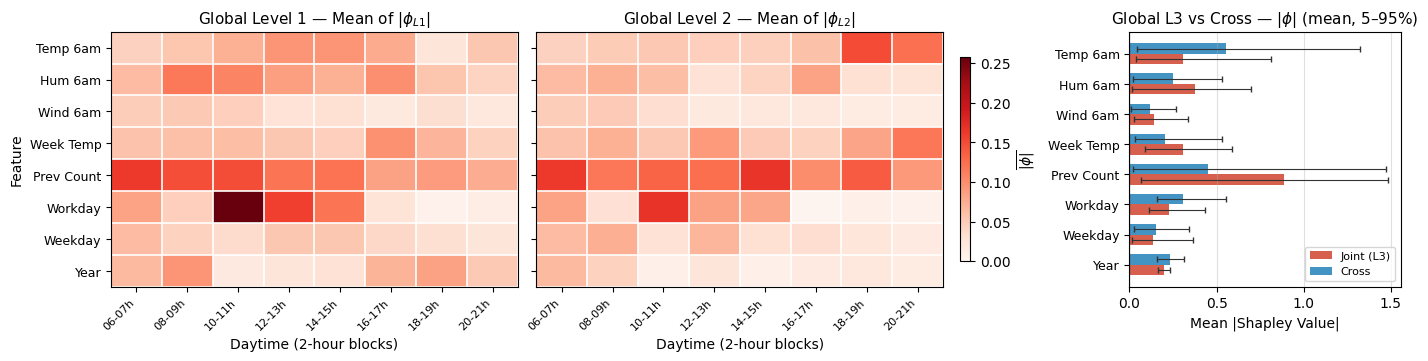

In [17]:
global_phi_L1    = np.abs(all_phi_L1).mean(axis=0)
global_phi_L2    = np.abs(all_phi_L2).mean(axis=0)
global_phi_L3    = np.abs(all_phi_L3).mean(axis=0)
global_phi_cross = np.abs(all_phi_L1.sum(axis=1) - all_phi_L3).mean(axis=0)

# 5%/95% quantile bands across instances (for the L3 + Cross barplot)
phi_L3_q    = np.quantile(np.abs(all_phi_L3),                              [0.05, 0.95], axis=0)
phi_cross_q = np.quantile(np.abs(all_phi_L1.sum(axis=1) - all_phi_L3),    [0.05, 0.95], axis=0)
xerr_L3     = np.stack([global_phi_L3    - phi_L3_q[0],    phi_L3_q[1]    - global_phi_L3])
xerr_cross  = np.stack([global_phi_cross - phi_cross_q[0], phi_cross_q[1] - global_phi_cross])

# Shared color scale for L1 and L2 heatmaps -> direct visual comparison of marginal vs sequential
vmax_shared = float(max(global_phi_L1.max(), global_phi_L2.max()))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), layout='constrained',
                         gridspec_kw={'width_ratios': [1.5, 1.5, 1]})

# --- L1 Heatmap ---
ax = axes[0]
im = ax.imshow(global_phi_L1.T, aspect='auto', cmap='Reds', vmin=0, vmax=vmax_shared)
ax.set_title('Global Level 1 — Mean of $|\\phi_{L1}|$', fontsize=11)
ax.set_xlabel('Daytime (2-hour blocks)')
ax.set_ylabel('Feature')
ax.set_xticks(np.arange(T))
ax.set_xticklabels(BLOCK_LABELS, rotation=45, ha='right', fontsize=8)
ax.set_yticks(np.arange(p))
ax.set_yticklabels(FEATURE_LABELS, fontsize=9)
ax.set_xticks(np.arange(T) + 0.5, minor=True)
ax.set_yticks(np.arange(p) + 0.5, minor=True)
ax.grid(which='minor', color='white', linewidth=1.2)
ax.tick_params(which='minor', length=0)

# --- L2 Heatmap (shared color scale with L1) ---
ax = axes[1]
im = ax.imshow(global_phi_L2.T, aspect='auto', cmap='Reds', vmin=0, vmax=vmax_shared)
ax.set_title('Global Level 2 — Mean of $|\\phi_{L2}|$', fontsize=11)
ax.set_xlabel('Daytime (2-hour blocks)')
ax.set_xticks(np.arange(T))
ax.set_xticklabels(BLOCK_LABELS, rotation=45, ha='right', fontsize=8)
ax.set_yticks(np.arange(p))
ax.set_yticklabels([])
ax.set_xticks(np.arange(T) + 0.5, minor=True)
ax.set_yticks(np.arange(p) + 0.5, minor=True)
ax.grid(which='minor', color='white', linewidth=1.2)
ax.tick_params(which='minor', length=0)
fig.colorbar(im, ax=axes[:2], shrink=0.8, label='$\\overline{|\\phi|}$', pad=0.02)

# --- L3 + Cross Barplot with 5/95% quantile errorbars across instances ---
ax = axes[2]
y_pos = np.arange(p)
bw = 0.35
ax.barh(y_pos + bw/2, global_phi_L3,    bw, xerr=xerr_L3,
        label='Joint (L3)', color='#d6604d',
        error_kw={'lw': 0.8, 'capsize': 2.5, 'ecolor': '0.2'})
ax.barh(y_pos - bw/2, global_phi_cross, bw, xerr=xerr_cross,
        label='Cross',      color='#4393c3',
        error_kw={'lw': 0.8, 'capsize': 2.5, 'ecolor': '0.2'})
ax.set_title('Global L3 vs Cross — $|\\phi|$ (mean, 5–95%)', fontsize=11)
ax.set_xlabel('Mean |Shapley Value|')
ax.set_yticks(y_pos)
ax.set_yticklabels(FEATURE_LABELS, fontsize=9)
ax.yaxis.set_inverted(True)
ax.axvline(0, color='black', lw=0.8)
ax.legend(fontsize=8)
ax.grid(True, axis='x', alpha=0.4)

plt.savefig(plot_dir + 'entropy_global.pdf', bbox_inches='tight')
plt.show()


## 8) SHAP vs. Entropy-Shapley: Mean vs. Uncertainty Attribution (Figure D.3)

We compare standard SHAP values (attributing the **predicted mean** $\hat{\mu}_t(\mathbf{x})$) with our Entropy-Shapley values (attributing the **marginal entropy** $H(Y_t \mid \mathbf{x})$,  **sequential entropy** $H(Y_t \mid Y_{<t}, \mathbf{x})$ and  **joint entropy** $H(Y \mid \mathbf{x})$), all computed locally for the workday and weekend instances. SHAP is computed component-wise via `TreeExplainer` on the NGBoost `loc`-trees (one per horizon).

These are *fundamentally different quantities* of the same predictive distribution – one measured in rentals, the other in nats – so there is no reason for the rankings to align. The point of the comparison is to make the decoupling explicit: features that strongly drive the mean (e.g. `Workday`) need not drive the joint uncertainty, and vice versa (e.g. `Hum 6am`, `Temp 6am`).


In [18]:
import shap

instances_array = np.concatenate([encode_df(x_inst) for _, x_inst in instances], axis = 0)

# SHAP for loc trees, componentwise (one TreeExplainer per horizon)
shap_loc = np.zeros((len(instances), T, p))  # (n_inst, T, p)
for t in range(T):
    explainer = shap.TreeExplainer(model, model_output=t, feature_names=FEATURES)
    sv = explainer(instances_array)
    # Group feature importance by original feature (sum importance of encoded features)
    shap_loc[:, t, :] = np.column_stack([sv.values[:, idx].sum(axis=1) for idx in groups])  # (n_inst, p)

# shap_loc[inst_idx].T → (p, T)  — same layout as phi_L1_hm in the hierarchy plot
print("✓ SHAP loc computed:", shap_loc.shape)  # (2, 12, 8)

✓ SHAP loc computed: (2, 8, 8)


Computing global SHAP across test set...
✓ Saved global SHAP to ../results/5_2/global_shap.npy


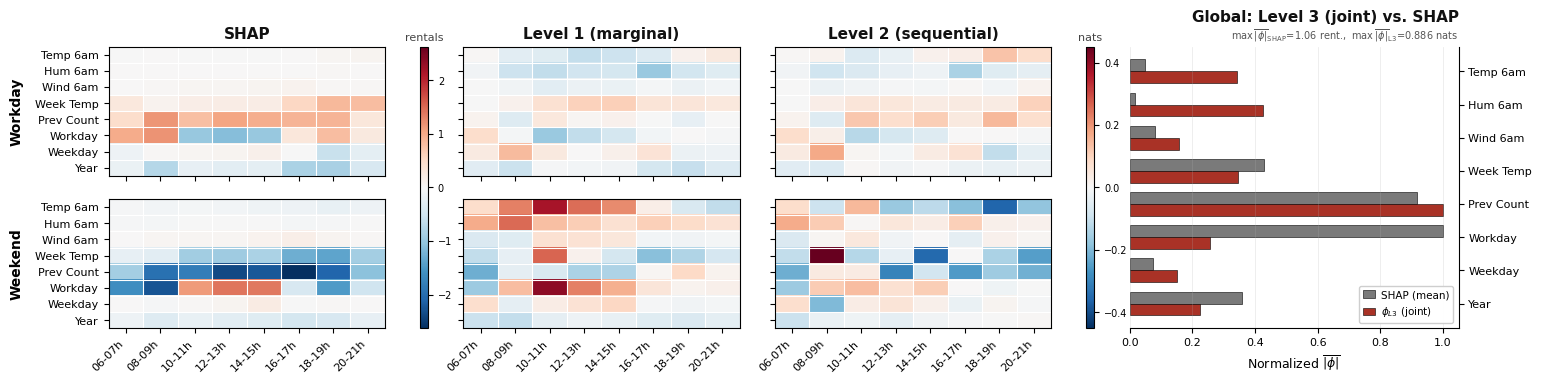

In [19]:
# === Appendix: SHAP vs Entropy-Shapley (L1, L2) heatmaps + Global L3 vs SHAP ===
inst_labels = list(all_results.keys())
n_inst      = len(inst_labels)

phi_L1_stack = np.stack([all_results[l]['phi_L1'] for l in inst_labels])
phi_L2_stack = np.stack([all_results[l]['phi_L2'] for l in inst_labels])
vlim_shap = float(np.max(np.abs(shap_loc)))
vlim_es   = float(max(np.max(np.abs(phi_L1_stack)), np.max(np.abs(phi_L2_stack))))

# --- Global SHAP across the whole test set (mean |.| over instances and horizons) ---
GLOBAL_SHAP_PATH = res_dir + "global_shap.npy"
if os.path.exists(GLOBAL_SHAP_PATH):
    global_shap_per_feat = np.load(GLOBAL_SHAP_PATH)
    print(f"✓ Loaded cached global SHAP from {GLOBAL_SHAP_PATH}")
else:
    print("Computing global SHAP across test set...")
    shap_test = np.zeros((len(X_test_enc), T, p))
    for t in range(T):
        explainer = shap.TreeExplainer(model, model_output=t, feature_names=FEATURES)
        sv = explainer(X_test_enc.values)
        shap_test[:, t, :] = np.column_stack([sv.values[:, idx].sum(axis=1) for idx in groups])
    global_shap_per_feat = np.abs(shap_test).mean(axis=(0, 1))    # (p,)
    np.save(GLOBAL_SHAP_PATH, global_shap_per_feat)
    print(f"✓ Saved global SHAP to {GLOBAL_SHAP_PATH}")

# --- Layout: 2 rows × 6 cols ---
TITLE_KW = dict(fontsize=11, fontweight='bold', color='#111', pad=6)

fig = plt.figure(figsize=(15, 4.4))
gs = gridspec.GridSpec(2, 6, figure=fig,
                       width_ratios=[1.05, 0.03, 1.05, 1.05, 0.03, 1.25],
                       wspace=0.18, hspace=0.18,
                       left=0.05, right=0.95, top=0.84, bottom=0.20)

col_data   = [shap_loc, phi_L1_stack, phi_L2_stack]
col_titles = ['SHAP', 'Level 1 (marginal)', 'Level 2 (sequential)']
col_vlims  = [vlim_shap, vlim_es, vlim_es]
heat_cols  = [0, 2, 3]

ims = [None] * 3
for k, c_grid in enumerate(heat_cols):
    for r in range(n_inst):
        ax = fig.add_subplot(gs[r, c_grid])
        hm = col_data[k][r].T   # (p, T)
        im = ax.imshow(hm, aspect='auto', cmap='RdBu_r',
                       vmin=-col_vlims[k], vmax=col_vlims[k])
        ims[k] = im

        ax.set_yticks(np.arange(p))
        if k == 0:
            ax.set_yticklabels(FEATURE_LABELS, fontsize=8)
            ax.set_ylabel(inst_labels[r], fontsize=10, fontweight='bold', labelpad=8)
        else:
            ax.set_yticklabels([])

        ax.set_xticks(np.arange(T))
        if r == n_inst - 1:
            ax.set_xticklabels(BLOCK_LABELS, rotation=45, ha='right', fontsize=8)
        else:
            ax.set_xticklabels([])

        ax.set_xticks(np.arange(T) + 0.5, minor=True)
        ax.set_yticks(np.arange(p) + 0.5, minor=True)
        ax.grid(which='minor', color='white', linewidth=0.8)
        ax.tick_params(which='minor', length=0)
        ax.tick_params(labelsize=8)

        if r == 0:
            ax.set_title(col_titles[k], **TITLE_KW)

# Colorbars: short unit headers above each cbar (units stay visible without crowding)
cax_shap = fig.add_subplot(gs[:, 1])
cax_es   = fig.add_subplot(gs[:, 4])
cb1 = fig.colorbar(ims[0], cax=cax_shap)
cb2 = fig.colorbar(ims[1], cax=cax_es)
for cb in (cb1, cb2):
    cb.ax.tick_params(labelsize=7)
cax_shap.set_title('rentals', fontsize=8, pad=4, color='#444')
cax_es.set_title('nats',     fontsize=8, pad=4, color='#444')

# --- Right: global L3 vs global SHAP (no error bars) ---
ax_g = fig.add_subplot(gs[:, 5])

g_shap_norm = global_shap_per_feat / global_shap_per_feat.max()
g_L3_norm   = global_phi_L3        / global_phi_L3.max()
y_pos = np.arange(p)
bw = 0.36

ax_g.barh(y_pos - bw/2, g_shap_norm, bw,
          color='#7a7a7a', edgecolor='black', lw=0.4, label='SHAP (mean)')
ax_g.barh(y_pos + bw/2, g_L3_norm,   bw,
          color='#a93226', edgecolor='black', lw=0.4, label=r'$\phi_{L3}$ (joint)')

ax_g.set_yticks(y_pos)
ax_g.set_yticklabels(FEATURE_LABELS, fontsize=8)
ax_g.yaxis.tick_right()
ax_g.yaxis.set_label_position('right')
ax_g.invert_yaxis()
ax_g.set_xlim(0, 1.05)
ax_g.set_xlabel(r'Normalized $\overline{|\phi|}$', fontsize=9)
ax_g.set_title('Global: Level 3 (joint) vs. SHAP',
               **{**TITLE_KW, 'pad': 18, 'loc': 'right'})
ax_g.spines[['top', 'left']].set_visible(False)
ax_g.grid(True, axis='x', alpha=0.3, lw=0.5)
ax_g.tick_params(labelsize=8)
ax_g.legend(fontsize=7.5, loc='lower right', framealpha=0.95,
            handlelength=1.2, handletextpad=0.5)

# Per-method absolute max (so the normalization scale isn't lost)
sub = (rf'$\max\,\overline{{|\phi|}}_{{\mathrm{{SHAP}}}}\!=\!{global_shap_per_feat.max():.3g}$ rent.,  '
       rf'$\max\,\overline{{|\phi|}}_{{\mathrm{{L3}}}}\!=\!{global_phi_L3.max():.3g}$ nats')
ax_g.text(1.0, 1.012, sub, transform=ax_g.transAxes, ha='right', va='bottom',
          fontsize=7, color='#555')

plt.savefig(plot_dir + 'shap_vs_es.pdf', bbox_inches='tight')
plt.show()


In [20]:
print("✅  Done with experiments and plotting.")
print(f"Total runtime: {(time.time() - start_time) / 60:.2f} minutes")

✅  Done with experiments and plotting.
Total runtime: 7.16 minutes
